In [1]:
#!/usr/bin/env python3
# encoding: utf-8
#
# Copyright (C) 2024 Max Planck Institute for Multidisclplinary Sciences
# Copyright (C) 2024 Bharti Arora <bharti.arora@mpinat.mpg.de>
# Copyright (C) 2024 Ajinkya Kulkarni <ajinkya.kulkarni@mpinat.mpg.de>
#
# This program is free software: you can redistribute it and/or modify
# it under the terms of the GNU Affero General Public License as
# published by the Free Software Foundation, either version 3 of the
# License, or (at your option) any later version.
#
# This program is distributed in the hope that it will be useful,
# but WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
# GNU Affero General Public License for more details.
#
# You should have received a copy of the GNU Affero General Public License
# along with this program. If not, see <https://www.gnu.org/licenses/>.

########################################################################################

In [2]:
import os
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
from tifffile import imread, imwrite
from stardist import export_imagej_rois, random_label_cmap
from stardist.models import StarDist2D
from stardist.utils import fill_label_holes
import pandas as pd
import cv2
from contextlib import redirect_stdout
from skimage.measure import regionprops_table

import sys
# Don't generate the __pycache__ folder locally
sys.dont_write_bytecode = True 

# Make src/ importable when this notebook is run from the notebooks/ folder
sys.path.insert(0, os.path.join('..', 'src'))

from modules_histo import *

from IPython.display import display
from PIL import Image as PILImage

# Inline figure resolution. Deliberately lower than the 300 dpi used for the saved
# files: these figures are embedded as base64 PNGs inside the .ipynb, so a high dpi
# makes the committed notebook enormous and slow to render on GitHub.
plt.rcParams['figure.dpi'] = 60


In [3]:
# Directories
input_folder  = os.path.join('..', 'sample_data', 'histology')
output_folder = os.path.join('..', 'output_data', 'histology')

########################################################################################

# Ensure the output subfolders exist
os.makedirs(os.path.join(output_folder, 'labeled'), exist_ok=True)
os.makedirs(os.path.join(output_folder, 'density'), exist_ok=True)
os.makedirs(os.path.join(output_folder, 'circularity'), exist_ok=True)
os.makedirs(os.path.join(output_folder, 'results'), exist_ok=True)
os.makedirs(os.path.join(output_folder, 'packaging'), exist_ok=True)
os.makedirs(os.path.join(output_folder, 'area'), exist_ok=True)

########################################################################################

model = StarDist2D.from_pretrained('2D_versatile_he')

########################################################################################

all_images_results = pd.DataFrame(columns=['Filename', 'Percentage_Area_high_nuclei', 
                                           'Percentage_Area_low_nuclei'])

filenames = sorted(os.listdir(input_folder))

Found model '2D_versatile_he' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.692478, nms_thresh=0.3.


Using prob_thresh: 0.4
Using nms_thresh: 0.3


  0%|          | 0/4 [00:00<?, ?it/s]

 25%|██▌       | 1/4 [00:00<00:01,  2.50it/s]

 50%|█████     | 2/4 [00:00<00:00,  3.63it/s]

 75%|███████▌  | 3/4 [00:00<00:00,  4.27it/s]

...

100%|██████████| 4/4 [00:00<00:00,  5.23it/s]

489400265.py (83): The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


  0%|          | 0/956 [00:00<?, ?it/s]

  0%|          | 0/956 [00:00<?, ?it/s]

Mosaic saved to ../output_data/histology/sample_he_1_mosaic.png



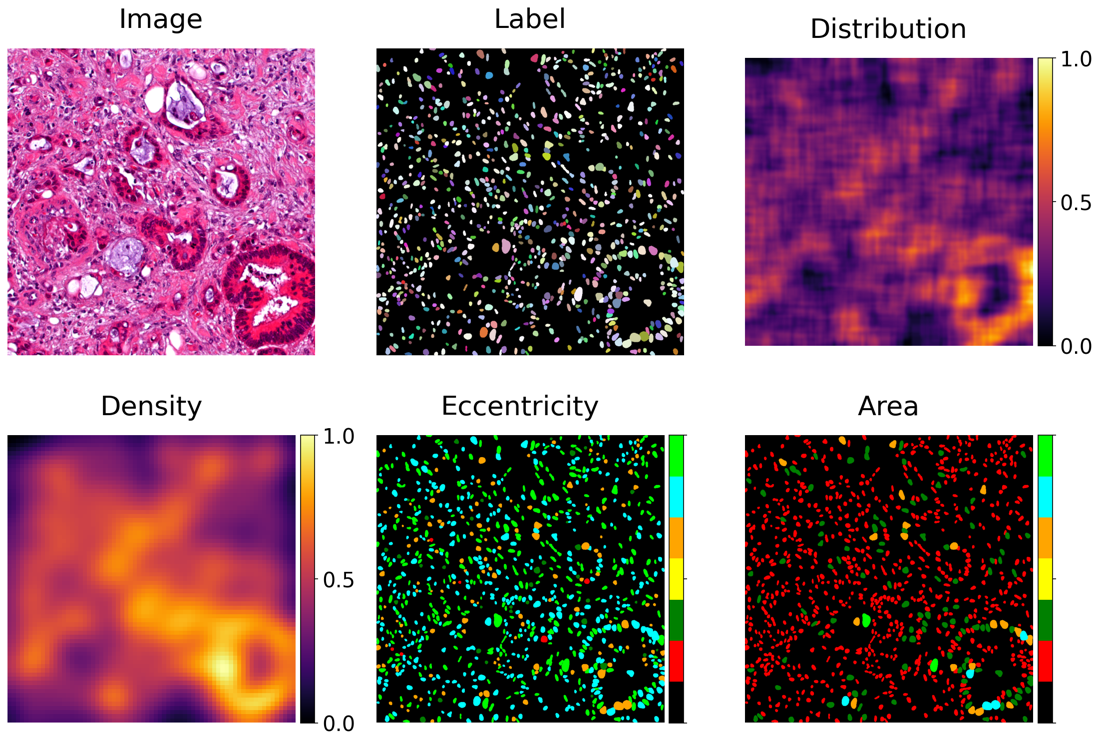

  0%|          | 0/4 [00:00<?, ?it/s]

Using prob_thresh: 0.4
Using nms_thresh: 0.3


 25%|██▌       | 1/4 [00:00<00:00,  5.06it/s]

 50%|█████     | 2/4 [00:00<00:00,  5.23it/s]

 75%|███████▌  | 3/4 [00:00<00:00,  5.24it/s]

...

100%|██████████| 4/4 [00:00<00:00,  4.98it/s]

100%|██████████| 4/4 [00:00<00:00,  4.96it/s]

  0%|          | 0/708 [00:00<?, ?it/s]

  0%|          | 0/708 [00:00<?, ?it/s]

Mosaic saved to ../output_data/histology/sample_he_2_mosaic.png



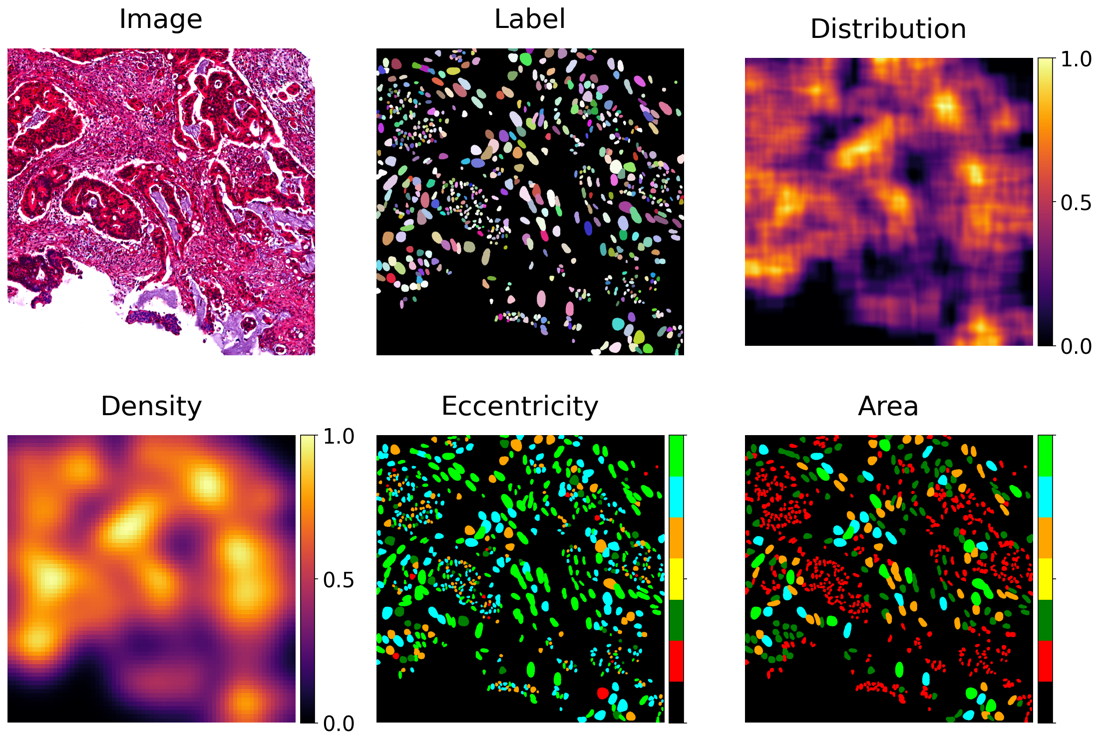

  0%|          | 0/4 [00:00<?, ?it/s]

Using prob_thresh: 0.4
Using nms_thresh: 0.3


 25%|██▌       | 1/4 [00:00<00:00,  4.66it/s]

 50%|█████     | 2/4 [00:00<00:00,  3.36it/s]

 75%|███████▌  | 3/4 [00:00<00:00,  4.00it/s]

...

100%|██████████| 4/4 [00:00<00:00,  4.89it/s]

100%|██████████| 4/4 [00:00<00:00,  4.81it/s]

  0%|          | 0/1598 [00:00<?, ?it/s]

  0%|          | 0/1598 [00:00<?, ?it/s]

Mosaic saved to ../output_data/histology/sample_he_3_mosaic.png



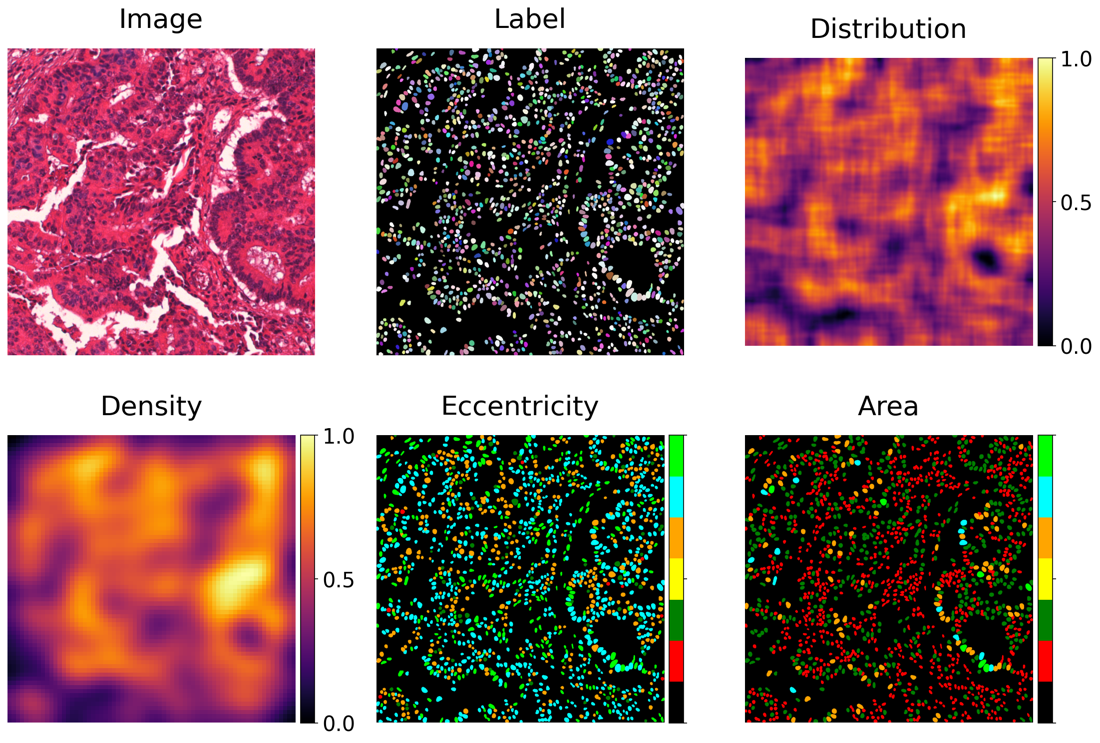

  0%|          | 0/4 [00:00<?, ?it/s]

Using prob_thresh: 0.4
Using nms_thresh: 0.3


 25%|██▌       | 1/4 [00:00<00:00,  3.66it/s]

 50%|█████     | 2/4 [00:00<00:00,  4.41it/s]

 75%|███████▌  | 3/4 [00:00<00:00,  4.57it/s]

...

100%|██████████| 4/4 [00:00<00:00,  4.54it/s]

100%|██████████| 4/4 [00:00<00:00,  4.42it/s]

  0%|          | 0/781 [00:00<?, ?it/s]

  0%|          | 0/781 [00:00<?, ?it/s]

Mosaic saved to ../output_data/histology/sample_he_4_mosaic.png



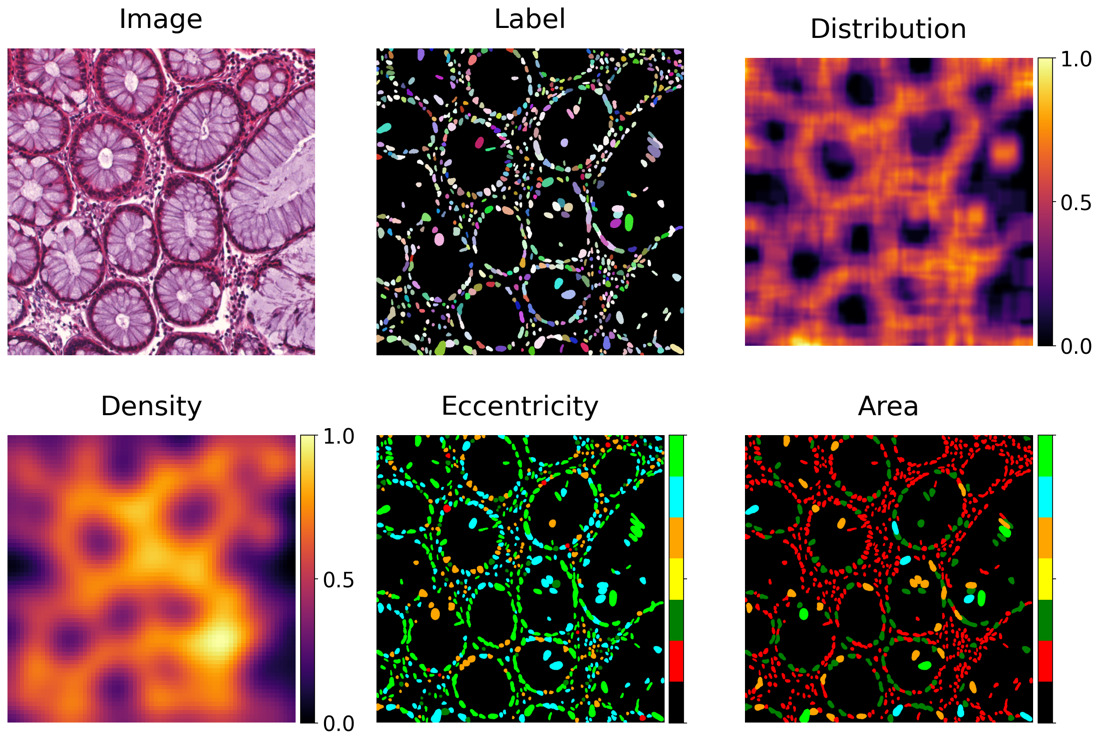

In [4]:
# Process all images in the input folder
for filename in filenames:
    
    if filename.endswith('.tif'):

        # Read image
        img = imread(os.path.join(input_folder, filename))
        
        # Use percentiles 25.0 and 85.0 for normalization
        mi, ma = np.percentile(img, [25.0, 85.0])
        normalizer = MyNormalizer(mi, ma)

        # Detection thresholds.
        # These MUST be passed into predict_instances_big() below. Assigning
        # model.config.prob_thresh has no effect: StarDist reads model.thresholds,
        # which is loaded from thresholds.json, so the assignment is silently
        # ignored and the model's built-in 0.6925 is used instead.
        prob_thresh = 0.4
        nms_thresh = 0.3

        print(f"Using prob_thresh: {prob_thresh}")
        print(f"Using nms_thresh: {nms_thresh}")

        with redirect_stdout(open(os.devnull, "w")) as f:
            # Predict instances and fill label holes
            labels, polys = model.predict_instances_big(img, axes='YXC', block_size=1000,
                                                        min_overlap=144, context=128,
                                                        normalizer=normalizer, n_tiles=(2,2,1),
                                                        prob_thresh=prob_thresh,
                                                        nms_thresh=nms_thresh,
                                                        show_progress = False)

        labels = fill_label_holes(labels)

        # Save labeled image
        imwrite(os.path.join(output_folder, 'labeled', filename), labels.astype(np.uint16))

        # Calculate and save nuclear density
        Local_Density_mean_filter = mean_filter(labels)
        
        Local_Density_mean_filter = normalize_density_maps(Local_Density_mean_filter)
        imwrite(os.path.join(output_folder, 'density', filename.replace('.tif', '_density.tif')),
               Local_Density_mean_filter.astype(np.float32))

        #Convert to gray and normalize
        image_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        image_gray = normalize_array(image_gray)

        ThresholdValueKey = 200
        
        # Create a mask for accepted pixels.
        # Count the number of pixels in the grayscale image that are above the threshold value.
        accepted_mask = image_gray < ThresholdValueKey

        # Applying the mask to the labels to nullify labels in non-accepted areas.
        # Create a masked array where labels in rejected areas are set to 0.
        labels_masked = labels * accepted_mask

        # Since labels_masked will have labels set to 0 in non-accepted areas,
        # count unique labels excluding 0 (background).
        unique_labels = np.unique(labels_masked)
        num_unique_labels = len(unique_labels) - 1 if 0 in unique_labels else len(unique_labels)
        
        # Obtain the Local_Density_mean_filter
        density_high_nuclei = Local_Density_mean_filter >= 0.5
        density_low_nuclei = Local_Density_mean_filter < 0.5
        
        
        # Apply the accepted_mask to density maps      
        density_high_nuclei_accepted = density_high_nuclei & accepted_mask
        density_low_nuclei_accepted = density_low_nuclei & accepted_mask
        

        # Percentage areas
        accepted_pixel_count = np.sum(accepted_mask)
        percentage_area_high_nuclei = (np.sum(density_high_nuclei_accepted) / accepted_pixel_count) * 100
        percentage_area_low_nuclei = (np.sum(density_low_nuclei_accepted) / accepted_pixel_count) * 100

        # Append the results for this image to the all_images_results DataFrame
        # DataFrame.append() was removed in pandas 2.0 — use pd.concat instead.
        # Column names must match those declared above ('high'/'low', not 'High'/'Low'),
        # otherwise pandas silently creates a second pair of columns.
        all_images_results = pd.concat([
            all_images_results,
            pd.DataFrame([{
                'Filename': filename,
                'Percentage_Area_high_nuclei': percentage_area_high_nuclei,
                'Percentage_Area_low_nuclei': percentage_area_low_nuclei
            }])
        ], ignore_index=True)

        
        # Calculate and save nuclear packaging
        Local_Packing = weighted_kde_density_map(labels, num_points = 5000)
        Local_Packing = normalize_density_maps(Local_Packing)
        imwrite(os.path.join(output_folder, 'packaging', filename.replace('.tif', '_packaging.tif')),
               Local_Packing.astype(np.float32))

        # Create a Pandas DataFrame to store the region properties
        label_properties = regionprops_table(labels, intensity_image=img,
                                             properties=('label', 'area', 'eccentricity'))
        dataframe = pd.DataFrame(label_properties)

        num_clusters = 6

        # Calculate and save binned eccentricity
        eccentricity_binned_image = make_binned_image(labels, label_properties,'eccentricity', num_clusters)
        imwrite(os.path.join(output_folder, 'circularity', filename.replace('.tif', '_circularity.tif')),
               eccentricity_binned_image)

         # Calculate and save binned area
        area_binned_image = make_binned_image(labels, label_properties, 'area', num_clusters)
        imwrite(os.path.join(output_folder, 'area', filename.replace('.tif', '_area.tif')), area_binned_image)

        # Create and save mosaic
        make_mosaic_and_save(img, labels, num_clusters, Local_Density_mean_filter,
                             Local_Packing, eccentricity_binned_image, area_binned_image,
                             filename, output_folder)

        # Show the saved mosaic inline, downscaled so the committed notebook stays small
        mosaic_path = os.path.join(output_folder, filename.replace('.tif', '_mosaic.png'))
        mosaic = PILImage.open(mosaic_path)
        mosaic.thumbnail((1100, 1100))
        display(mosaic)

        all_images_results.to_csv(os.path.join(output_folder, 'results', 
                                               'nuclei_density_groups_percentage_area.csv'), index=False)